# Bayesian Gravity Model of Senate Campaign Donations

Bayesian re-implementation of **Model C** (GP spatial + destination FE) from `model_with_covariates.ipynb`.

Key differences from the mgcv `bam()` fit:
- Explicit priors on all parameters (vs. REML penalty estimation)
- Full posterior distributions → credible intervals, not p-values
- Spatial term via **HSGP** (Hilbert-Space GP approximation, m=12×12=144 basis functions)
- Hierarchical prior on destination-state effects
- Inference: NUTS on a stratified 10 k subsample (~5–10 min on CPU) — see the ADVI cell for a faster full-data approximate fit

In [1]:
import pandas as pd
import numpy as np
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

np.random.seed(305)
print(f"PyMC {pm.__version__}  |  ArviZ {az.__version__}")

PyMC 5.28.5  |  ArviZ 0.23.4


In [2]:
df = pd.read_csv('model_data_2020.csv')
print(f"2020 data: {len(df):,} rows | "
      f"{df['ZIP_CODE'].nunique():,} origin ZIPs | "
      f"{df['CAND_OFFICE_ST'].nunique()} destination states")
df[['ZIP_CODE','STATE','CAND_OFFICE_ST','CAND_PTY_AFFILIATION',
    'LOG_DONATIONS','population_z','median_income_z',
    'prop_college_degree_or_higher_18plus_z','hs_z',
    'in_state','log_dist_z','lon','lat']].head(3)

2020 data: 157,757 rows | 17,473 origin ZIPs | 34 destination states


,ZIP_CODE,STATE,CAND_OFFICE_ST,CAND_PTY_AFFILIATION,LOG_DONATIONS,population_z,median_income_z,prop_college_degree_or_higher_18plus_z,hs_z,in_state,log_dist_z,lon,lat
0,1001,MA,AZ,DEM,5.799093,-0.451469,-0.594492,-0.317625,0.320932,0,1.136644,-72.6227,42.0702
1,1001,MA,AZ,REP,5.669881,-0.451469,-0.594492,-0.317625,0.320932,0,1.136644,-72.6227,42.0702
2,1001,MA,CO,DEM,5.521461,-0.451469,-0.594492,-0.317625,0.320932,0,0.879140,-72.6227,42.0702


In [3]:
# Drop 286 rows where log_dist_z is NaN (destination states with no centroid match)
df = df.dropna(subset=['log_dist_z']).copy()
print(f"After dropping NaN log_dist_z: {len(df):,} rows")

# Binary party indicator (DEM=0, REP=1)
df['REP'] = (df['CAND_PTY_AFFILIATION'] == 'REP').astype(int)

# Destination state integer codes (0-indexed, sorted for reproducibility)
states = sorted(df['CAND_OFFICE_ST'].unique())
state2idx = {s: i for i, s in enumerate(states)}
df['state_idx'] = df['CAND_OFFICE_ST'].map(state2idx).astype(int)
n_states = len(states)
print(f"{n_states} destination states: {states[:5]} ... {states[-3:]}")

# Feature matrix — all predictors already z-scored in the CSV
feature_cols = [
    'population_z', 'median_income_z',
    'prop_college_degree_or_higher_18plus_z', 'hs_z',
    'REP', 'in_state', 'log_dist_z',
]
feature_labels = [
    'population', 'median_income', 'college_%', 'hs_%',
    'REP vs DEM', 'in_state', 'log(dist)',
]

X_full         = df[feature_cols].values.astype(np.float64)
y_full         = df['LOG_DONATIONS'].values.astype(np.float64)
state_idx_full = df['state_idx'].values.astype(int)

# Scale lon/lat to [-1, 1] for HSGP boundary conditions
lon_half = (df['lon'].max() - df['lon'].min()) / 2
lat_half = (df['lat'].max() - df['lat'].min()) / 2
lon_sc   = (df['lon'].values - df['lon'].mean()) / lon_half
lat_sc   = (df['lat'].values - df['lat'].mean()) / lat_half
coords_full = np.stack([lon_sc, lat_sc], axis=-1)

assert not np.isnan(X_full).any(), "NaN in feature matrix"
print(f"\nX: {X_full.shape}  |  y mean={y_full.mean():.3f}, std={y_full.std():.3f}")
print(f"lon_scaled ∈ [{lon_sc.min():.3f}, {lon_sc.max():.3f}]")
print(f"lat_scaled ∈ [{lat_sc.min():.3f}, {lat_sc.max():.3f}]")

After dropping NaN log_dist_z: 157,471 rows
33 destination states: ['AL', 'AR', 'AZ', 'CO', 'DE'] ... ['VA', 'WV', 'WY']

X: (157471, 7)  |  y mean=6.347, std=1.615
lon_scaled ∈ [-1.140, 0.860]
lat_scaled ∈ [-1.110, 0.890]


## Model Specification

$$\log(\text{donation}_{ij}) \sim \mathcal{N}(\mu_{ij},\; \sigma^2)$$

$$\mu_{ij} = \alpha + \mathbf{x}_{ij}^\top \boldsymbol{\beta} + \gamma_{j} + f(\text{lon}_i, \text{lat}_i)$$

| Component | Distribution | Justification |
|-----------|-------------|---------------|
| Intercept $\alpha$ | $\mathcal{N}(6, 1.5^2)$ | outcome mean ≈ 6.3 |
| Fixed effects $\boldsymbol{\beta}$ | $\mathcal{N}(\mathbf{0}, \mathbf{I}_7)$ | regularizing; predictors are z-scored |
| State SD $\sigma_\gamma$ | $\text{HalfNormal}(0.5)$ | weakly informative on state-level variation |
| State FE $\gamma_j$ | $\mathcal{N}(0, \sigma_\gamma^2)$ | 34 destination states; hierarchical shrinkage |
| GP lengthscale $\ell$ | $\text{InverseGamma}(5, 5)$ | mode ≈ 0.83 in scaled coords ≈ 1,200 km |
| GP amplitude $\eta$ | $\text{HalfNormal}(0.5)$ | spatial effect bounded to ~0.5 log-donations |
| Residual SD $\sigma$ | $\text{HalfNormal}(1)$ | residual ≈ 1.3 in frequentist model |

**Spatial term**: HSGP with Matérn-5/2 kernel, m=[12,12]=144 basis functions —  
analogous to mgcv's `s(lon, lat, bs="gp", k=200)` but with explicit priors on  
kernel hyperparameters instead of REML penalty estimation.

In [4]:
def build_model(X, y, state_idx, coords, n_states):
    n, p = X.shape
    with pm.Model() as model:
        # Fixed effects
        alpha = pm.Normal('alpha', mu=6.0, sigma=1.5)
        beta  = pm.Normal('beta',  mu=0.0, sigma=1.0, shape=p)

        # Hierarchical destination-state effects
        sigma_state = pm.HalfNormal('sigma_state', sigma=0.5)
        gamma       = pm.Normal('gamma', mu=0.0, sigma=sigma_state, shape=n_states)

        # Spatial GP via HSGP (Hilbert-Space approximation)
        # c=1.5 expands the domain boundary to 1.5×max(|coord|) so all data stays inside
        ell      = pm.InverseGamma('ell', alpha=5.0, beta=5.0)   # lengthscale in scaled coords
        eta      = pm.HalfNormal('eta', sigma=0.5)               # GP amplitude
        cov_func = eta**2 * pm.gp.cov.Matern52(input_dim=2, ls=ell)
        gp       = pm.gp.HSGP(m=[12, 12], c=1.5, cov_func=cov_func)
        f        = gp.prior('f', X=coords)

        # Mean and likelihood
        mu    = alpha + pm.math.dot(X, beta) + gamma[state_idx] + f
        sigma = pm.HalfNormal('sigma', sigma=1.0)
        pm.Normal('y_obs', mu=mu, sigma=sigma, observed=y)
    return model, gp

# Verify parameter count on a tiny slice
_m, _ = build_model(X_full[:5], y_full[:5], state_idx_full[:5], coords_full[:5], n_states)
n_params = sum(v.size.eval() for v in _m.free_RVs)
print(f"Free parameters: {n_params}")
print("  alpha(1) + beta(7) + sigma_state(1) + gamma(34) + "
      "ell(1) + eta(1) + f_hsgp_coeffs(144) + sigma(1) = 190")

Free parameters: 189
  alpha(1) + beta(7) + sigma_state(1) + gamma(34) + ell(1) + eta(1) + f_hsgp_coeffs(144) + sigma(1) = 190


In [5]:
# Stratified subsample for NUTS
# Full dataset (~157k rows) would take hours on CPU; 10k captures the main patterns.
N_SUB = 10_000
rng   = np.random.default_rng(305)
sub   = rng.choice(len(df), size=N_SUB, replace=False)

X_sub      = X_full[sub]
y_sub      = y_full[sub]
state_sub  = state_idx_full[sub]
coords_sub = coords_full[sub]

print(f"Subsample: n={N_SUB:,}  (from {len(df):,} total rows)")
print(f"In-state fraction: {X_sub[:, 5].mean():.3f}  (full: {X_full[:, 5].mean():.3f})")
print(f"REP fraction:      {X_sub[:, 4].mean():.3f}  (full: {X_full[:, 4].mean():.3f})")

Subsample: n=10,000  (from 157,471 total rows)
In-state fraction: 0.077  (full: 0.079)
REP fraction:      0.450  (full: 0.449)


In [6]:
# NUTS sampling on the 10k subsample
# Expected runtime: ~5–10 min on CPU (2 chains × 1,500 steps; includes ~15s JIT compile)
# To speed up: set chains=1 or reduce draws
model_sub, gp_sub = build_model(X_sub, y_sub, state_sub, coords_sub, n_states)

with model_sub:
    idata = pm.sample(
        draws=1000,
        tune=500,
        chains=2,
        target_accept=0.85,
        random_seed=305,
        return_inferencedata=True,
    )

n_div = int(idata.sample_stats.diverging.values.sum())
print(f"Sampling complete. Divergences: {n_div} / {1000*2}  (want 0 or very few)")

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [alpha, beta, sigma_state, gamma, ell, eta, f_hsgp_coeffs, sigma]


Sampling 2 chains for 500 tune and 1_000 draw iterations (1_000 + 2_000 draws total) took 64 seconds.
There were 18 divergences after tuning. Increase `target_accept` or reparameterize.
We recommend running at least 4 chains for robust computation of convergence diagnostics


Sampling complete. Divergences: 18 / 2000  (want 0 or very few)


In [7]:
# Save trace — reload with az.from_netcdf('bayes_idata_nuts_n10k.nc') to skip resampling
idata.to_netcdf('bayes_idata_nuts_n10k.nc')
print("Saved bayes_idata_nuts_n10k.nc")

Saved bayes_idata_nuts_n10k.nc


=== NUTS convergence diagnostics ===
Max R-hat:    1.0100   (target < 1.01)
Min bulk-ESS: 579   (target > 200)
Min tail-ESS: 713

              mean     sd  hdi_2.5%  hdi_97.5%  r_hat  ess_bulk
alpha        6.146  0.271     5.654      6.695   1.00     639.0
beta[0]      0.224  0.013     0.196      0.248   1.00    3479.0
beta[1]     -0.139  0.021    -0.181     -0.098   1.00    2891.0
beta[2]      0.869  0.024     0.822      0.912   1.00    2702.0
beta[3]     -0.066  0.019    -0.104     -0.031   1.00    3113.0
beta[4]      0.192  0.030     0.134      0.251   1.00    3437.0
beta[5]      1.254  0.076     1.106      1.405   1.00    2677.0
beta[6]     -0.174  0.022    -0.214     -0.125   1.00    2580.0
sigma_state  0.570  0.079     0.429      0.725   1.00    2671.0
ell          0.854  0.262     0.453      1.402   1.01     579.0
eta          0.514  0.189     0.244      0.925   1.00     910.0
sigma        1.340  0.009     1.322      1.359   1.00    4642.0


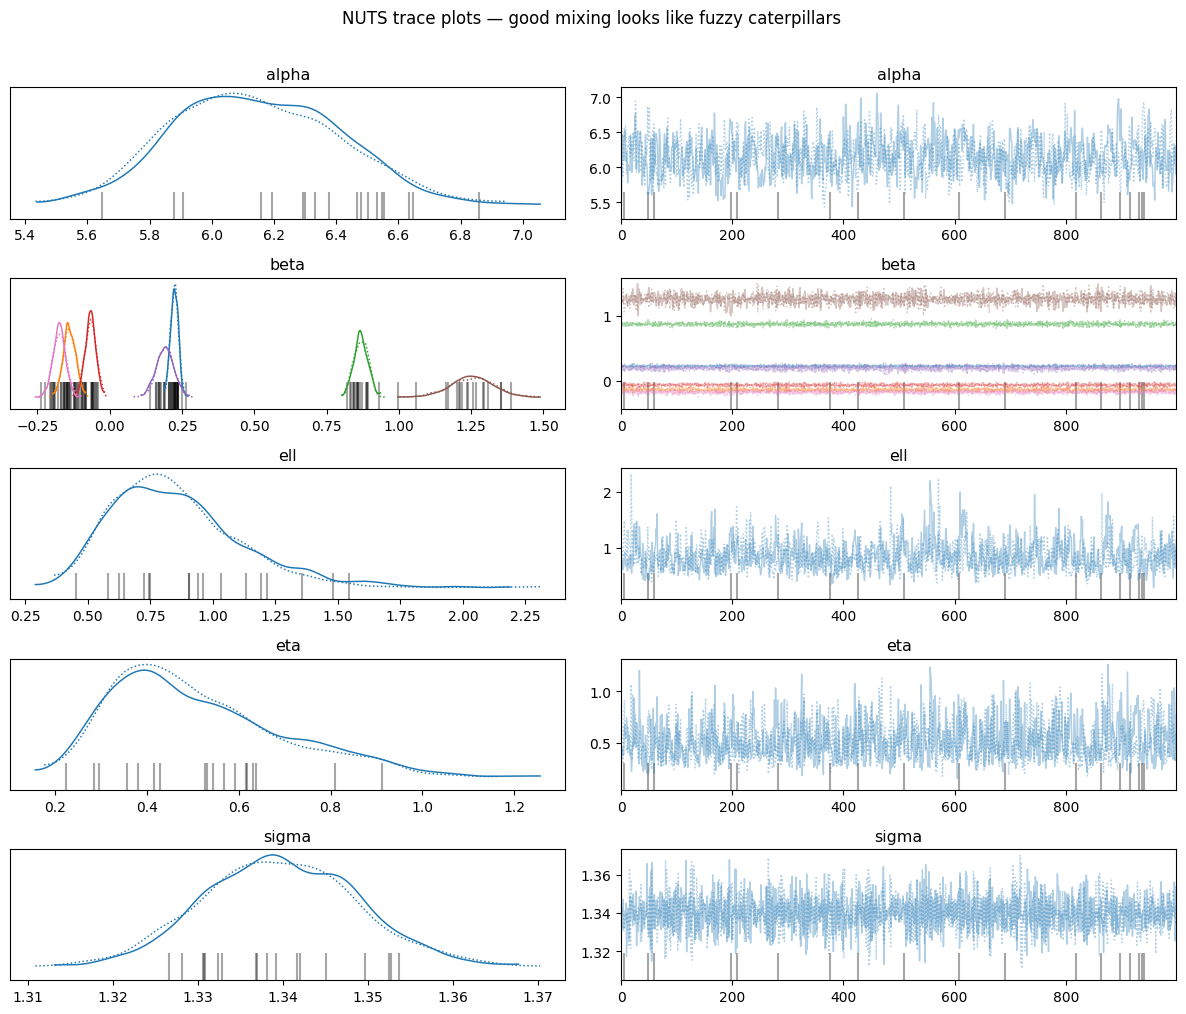

In [8]:
# Convergence diagnostics
summ = az.summary(idata, var_names=['alpha', 'beta', 'sigma_state', 'ell', 'eta', 'sigma'],
                  hdi_prob=0.95)

print("=== NUTS convergence diagnostics ===")
print(f"Max R-hat:    {summ['r_hat'].max():.4f}   (target < 1.01)")
print(f"Min bulk-ESS: {summ['ess_bulk'].min():.0f}   (target > 200)")
print(f"Min tail-ESS: {summ['ess_tail'].min():.0f}")
print()
print(summ[['mean', 'sd', 'hdi_2.5%', 'hdi_97.5%', 'r_hat', 'ess_bulk']].round(3).to_string())

az.plot_trace(idata, var_names=['alpha', 'beta', 'ell', 'eta', 'sigma'],
              combined=False, compact=True)
plt.suptitle('NUTS trace plots — good mixing looks like fuzzy caterpillars', y=1.01)
plt.tight_layout()
plt.savefig('bayes_trace.png', dpi=120, bbox_inches='tight')
plt.show()

## ADVI Alternative — Full Dataset (~5–10 min)

The cell below fits the **same model on all 157k rows** using mean-field ADVI instead of NUTS.
ADVI is orders of magnitude faster but assumes a diagonal (independent) posterior covariance,
so it underestimates correlations between parameters.  Use it for fast exploration or as a
warm-start; use the NUTS trace above for final inference.

Finished [100%]: Average Loss = 2.7127e+05
arviz - WARNING - Shape validation failed: input_shape: (1, 2000), minimum_shape: (chains=2, draws=4)


ADVI fit complete.
              mean     sd  hdi_2.5%  hdi_97.5%
alpha        6.035  0.004     6.027      6.042
beta[0]      0.239  0.004     0.232      0.246
beta[1]     -0.154  0.004    -0.161     -0.147
beta[2]      0.869  0.004     0.861      0.876
beta[3]     -0.066  0.004    -0.073     -0.058
beta[4]      0.125  0.006     0.114      0.136
beta[5]      1.434  0.013     1.405      1.458
beta[6]     -0.120  0.004    -0.128     -0.113
sigma_state  0.613  0.079     0.468      0.775
ell          0.345  0.006     0.333      0.357
eta          0.224  0.004     0.217      0.231
sigma        1.352  0.003     1.346      1.357


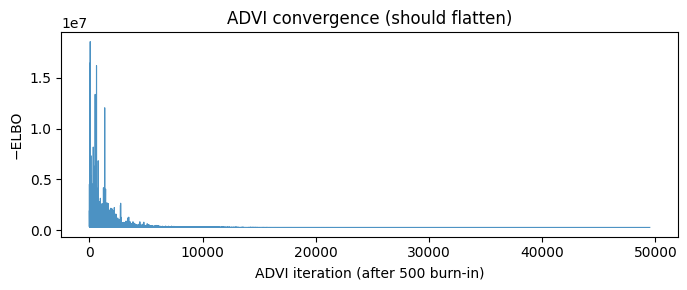

In [9]:
model_full, gp_full = build_model(
    X_full, y_full, state_idx_full, coords_full, n_states
)

with model_full:
    approx     = pm.fit(n=50_000, method='advi', random_seed=305, progressbar=True)
    idata_advi = approx.sample(draws=2000, random_seed=305)

print("ADVI fit complete.")
summ_advi = az.summary(idata_advi,
                       var_names=['alpha', 'beta', 'sigma_state', 'ell', 'eta', 'sigma'],
                       hdi_prob=0.95)
print(summ_advi[['mean', 'sd', 'hdi_2.5%', 'hdi_97.5%']].round(3).to_string())

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(approx.hist[500:], alpha=0.8, linewidth=0.8)
ax.set_xlabel('ADVI iteration (after 500 burn-in)')
ax.set_ylabel('−ELBO')
ax.set_title('ADVI convergence (should flatten)')
plt.tight_layout()
plt.savefig('bayes_advi_elbo.png', dpi=120, bbox_inches='tight')
plt.show()

=== Frequentist (n=157k, REML) vs Bayesian NUTS (n=10k subsample) ===
               freq_est  freq_lo  freq_hi  bayes_mean  bayes_lo  bayes_hi
predictor                                                                
population       0.2480   0.2405   0.2555       0.224     0.196     0.248
median_income   -0.1628  -0.1740  -0.1515      -0.139    -0.181    -0.098
college_%        0.8672   0.8550   0.8795       0.869     0.822     0.912
hs_%            -0.0626  -0.0725  -0.0527      -0.066    -0.104    -0.031
REP vs DEM       0.1247   0.1100   0.1394       0.192     0.134     0.251
in_state         1.4409   1.4022   1.4797       1.254     1.106     1.405
log(dist)       -0.1260  -0.1371  -0.1150      -0.174    -0.214    -0.125


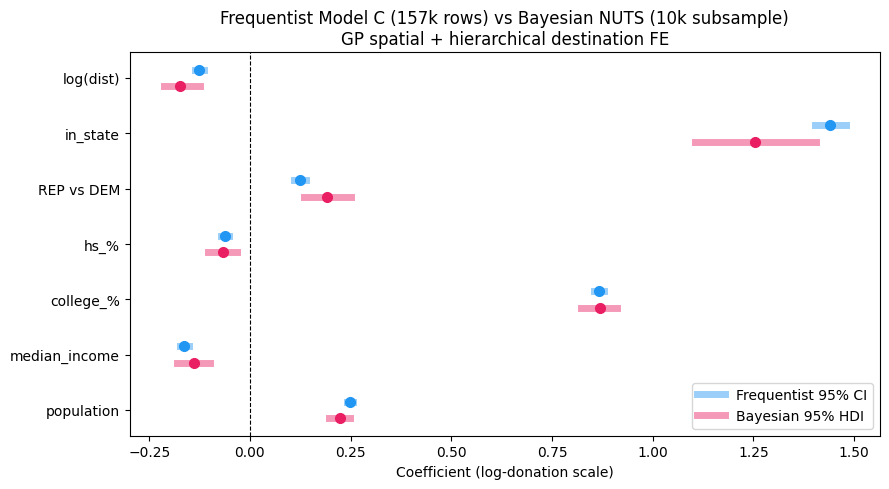

In [10]:
# Compare posterior (NUTS) to frequentist Model C
freq_df = pd.read_csv('coef_comparison.csv')
freq_C  = freq_df[freq_df['model'] == 'C_GP_spatial_destFE'].set_index('term')

freq_terms = [
    'population_z', 'median_income_z',
    'prop_college_degree_or_higher_18plus_z', 'hs_z',
    'CAND_PTY_AFFILIATIONREP', 'in_state', 'log_dist_z',
]

beta_summ = az.summary(idata, var_names=['beta'], hdi_prob=0.95)
beta_summ.index = feature_labels

rows = []
for i, (ft, lbl) in enumerate(zip(freq_terms, feature_labels)):
    f_est = freq_C.loc[ft, 'estimate']  if ft in freq_C.index else np.nan
    f_se  = freq_C.loc[ft, 'std_error'] if ft in freq_C.index else np.nan
    rows.append({
        'predictor':  lbl,
        'freq_est':   f_est,
        'freq_lo':    f_est - 1.96*f_se,
        'freq_hi':    f_est + 1.96*f_se,
        'bayes_mean': beta_summ.loc[lbl, 'mean'],
        'bayes_lo':   beta_summ.loc[lbl, 'hdi_2.5%'],
        'bayes_hi':   beta_summ.loc[lbl, 'hdi_97.5%'],
    })
comp = pd.DataFrame(rows)
print("=== Frequentist (n=157k, REML) vs Bayesian NUTS (n=10k subsample) ===")
print(comp.set_index('predictor').round(4).to_string())

fig, ax = plt.subplots(figsize=(9, 5))
y_pos = np.arange(len(feature_labels))
for i, row in comp.iterrows():
    ax.plot([row.freq_lo, row.freq_hi], [y_pos[i]+0.15]*2,
            color='#2196F3', linewidth=5, alpha=0.45,
            label='Frequentist 95% CI' if i==0 else '')
    ax.plot(row.freq_est, y_pos[i]+0.15, 'o', color='#2196F3', markersize=7)
    ax.plot([row.bayes_lo, row.bayes_hi], [y_pos[i]-0.15]*2,
            color='#E91E63', linewidth=5, alpha=0.45,
            label='Bayesian 95% HDI' if i==0 else '')
    ax.plot(row.bayes_mean, y_pos[i]-0.15, 'o', color='#E91E63', markersize=7)

ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_yticks(y_pos)
ax.set_yticklabels(feature_labels)
ax.set_xlabel('Coefficient (log-donation scale)')
ax.set_title('Frequentist Model C (157k rows) vs Bayesian NUTS (10k subsample)\n'
             'GP spatial + hierarchical destination FE')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('bayes_vs_freq_coefs.png', dpi=150, bbox_inches='tight')
plt.show()

Sampling: [y_obs]


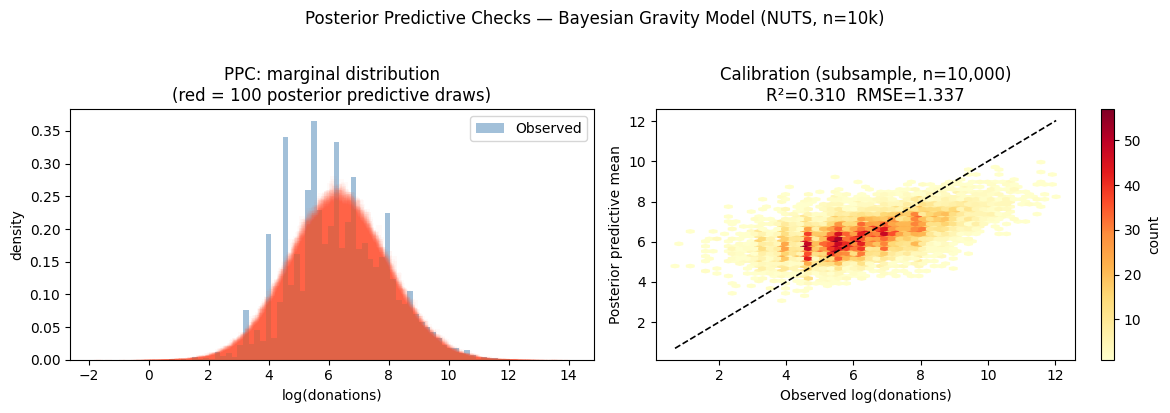

In-sample R²=0.3104  RMSE=1.3365
(Frequentist Model C in-sample R² on 2020 full data: ~0.305)


In [11]:
with model_sub:
    ppc = pm.sample_posterior_predictive(idata, random_seed=305, progressbar=False)

y_ppc      = ppc.posterior_predictive['y_obs'].values   # (chains, draws, n_sub)
y_ppc_flat = y_ppc.reshape(-1, N_SUB)
y_pred_mean = y_ppc_flat.mean(axis=0)

resid = y_sub - y_pred_mean
rmse  = np.sqrt((resid**2).mean())
r2    = 1 - (resid**2).sum() / ((y_sub - y_sub.mean())**2).sum()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Marginal distribution overlay
axes[0].hist(y_sub, bins=60, alpha=0.5, color='steelblue', density=True, label='Observed')
for i in np.random.choice(len(y_ppc_flat), 100, replace=False):
    axes[0].hist(y_ppc_flat[i], bins=60, alpha=0.03, color='tomato', density=True)
axes[0].set_xlabel('log(donations)')
axes[0].set_ylabel('density')
axes[0].set_title('PPC: marginal distribution\n(red = 100 posterior predictive draws)')
axes[0].legend()

# Calibration
hb = axes[1].hexbin(y_sub, y_pred_mean, gridsize=50, cmap='YlOrRd', mincnt=1)
plt.colorbar(hb, ax=axes[1], label='count')
lo = min(y_sub.min(), y_pred_mean.min())
hi = max(y_sub.max(), y_pred_mean.max())
axes[1].plot([lo, hi], [lo, hi], 'k--', linewidth=1.2)
axes[1].set_xlabel('Observed log(donations)')
axes[1].set_ylabel('Posterior predictive mean')
axes[1].set_title(f'Calibration (subsample, n={N_SUB:,})\nR²={r2:.3f}  RMSE={rmse:.3f}')

plt.suptitle('Posterior Predictive Checks — Bayesian Gravity Model (NUTS, n=10k)', y=1.02)
plt.tight_layout()
plt.savefig('bayes_ppc.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"In-sample R²={r2:.4f}  RMSE={rmse:.4f}")
print(f"(Frequentist Model C in-sample R² on 2020 full data: ~0.305)")